<a href="https://colab.research.google.com/github/carolembomegni/Projet_SD_Detection_Tumeurs/blob/Loic-Projet/EntrainementModeleVGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import gdown
import zipfile
import os

file_id = "1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc"
url = f"https://drive.google.com/uc?id={file_id}"

output = "dataset.zip"

gdown.download(url, output, quiet=False)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall("/content/")

# Détection du dossier dataset
possible_dirs = [d for d in os.listdir("/content") if "brain" in d.lower()]

if len(possible_dirs) > 0:
    DATA_PATH = f"/content/{possible_dirs[0]}"
else:
    raise Exception("Dataset folder not found")

print("DATA_PATH =", DATA_PATH)

Downloading...
From (original): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc
From (redirected): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc&confirm=t&uuid=c3732753-7982-456d-b766-7cfcdc9c7d96
To: /content/dataset.zip
100%|██████████| 94.3M/94.3M [00:02<00:00, 41.8MB/s]


DATA_PATH = /content/brain-tumor-classification-mri


In [2]:
import os
import shutil
from pathlib import Path

# =====================================
# CHEMINS
# =====================================
src_root = Path(DATA_PATH)      # chemin détecté automatiquement par le bloc d'import
dst_root = Path("/content/Binary")

splits = ["Training", "Testing"]
tumor_folders = ["glioma_tumor", "meningioma_tumor", "pituitary_tumor"]
no_tumor_folder = "no_tumor"

# =====================================
# NETTOYAGE SI LE DOSSIER EXISTE DEJA
# =====================================
if dst_root.exists():
    shutil.rmtree(dst_root)

# =====================================
# CREATION DES DOSSIERS DE DESTINATION
# =====================================
for split in splits:
    (dst_root / split / "tumor").mkdir(parents=True, exist_ok=True)
    (dst_root / split / "no_tumor").mkdir(parents=True, exist_ok=True)

# =====================================
# FONCTION DE COPIE SECURISEE
# =====================================
def safe_copy(src_file: Path, dst_dir: Path):
    dst_file = dst_dir / src_file.name
    if dst_file.exists():
        dst_file = dst_dir / f"{src_file.stem}_{abs(hash(str(src_file))) % 10**8}{src_file.suffix}"
    shutil.copy2(src_file, dst_file)

# =====================================
# FUSION DES CLASSES EN BINAIRE
# =====================================
for split in splits:
    # Fusion des classes tumor
    for cls in tumor_folders:
        cls_path = src_root / split / cls
        if cls_path.exists():
            for img in cls_path.rglob("*"):
                if img.is_file():
                    safe_copy(img, dst_root / split / "tumor")

    # Copie de la classe no_tumor
    cls_path = src_root / split / no_tumor_folder
    if cls_path.exists():
        for img in cls_path.rglob("*"):
            if img.is_file():
                safe_copy(img, dst_root / split / "no_tumor")

# =====================================
# VERIFICATION
# =====================================
print("✅ Fusion binaire terminée.")
print("Dossier source :", src_root)

print("\nTraining classes :", os.listdir(dst_root / "Training"))
print("Testing classes  :", os.listdir(dst_root / "Testing"))

print("\nNombre d'images Training/tumor    :", len(list((dst_root / "Training" / "tumor").glob("*"))))
print("Nombre d'images Training/no_tumor :", len(list((dst_root / "Training" / "no_tumor").glob("*"))))
print("Nombre d'images Testing/tumor     :", len(list((dst_root / "Testing" / "tumor").glob("*"))))
print("Nombre d'images Testing/no_tumor  :", len(list((dst_root / "Testing" / "no_tumor").glob("*"))))

✅ Fusion binaire terminée.
Dossier source : /content/brain-tumor-classification-mri

Training classes : ['tumor', 'no_tumor']
Testing classes  : ['tumor', 'no_tumor']

Nombre d'images Training/tumor    : 2475
Nombre d'images Training/no_tumor : 395
Nombre d'images Testing/tumor     : 289
Nombre d'images Testing/no_tumor  : 105


In [3]:
import tensorflow as tf

import os

# ==============================

# CHEMINS DU DATASET BINAIRE

# ==============================

train_dir = "/content/Binary/Training"

test_dir  = "/content/Binary/Testing"

print("Classes train :", os.listdir(train_dir))

print("Classes test  :", os.listdir(test_dir))

# ==============================

# CHARGEMENT DU DATASET TRAIN

# ==============================

train_ds = tf.keras.utils.image_dataset_from_directory(

    train_dir,

    image_size=(224, 224),

    batch_size=32,

    label_mode='binary',

    shuffle=True,

    seed=42

)

# ==============================

# CHARGEMENT DU DATASET TEST

# ==============================

test_ds = tf.keras.utils.image_dataset_from_directory(

    test_dir,

    image_size=(224, 224),

    batch_size=32,

    label_mode='binary',

    shuffle=False

)


Classes train : ['tumor', 'no_tumor']
Classes test  : ['tumor', 'no_tumor']
Found 2870 files belonging to 2 classes.
Found 394 files belonging to 2 classes.


In [4]:
from PIL import Image
from pathlib import Path

# ==============================
# CHEMINS DU DATASET BINAIRE
# ==============================
train_dir = Path("/content/Binary/Training")
test_dir  = Path("/content/Binary/Testing")

# ==============================
# FONCTION SUPPRESSION IMAGES CORROMPUES
# ==============================
def remove_corrupted_images(folder):
    removed = 0
    for img_path in folder.rglob("*"):
        if img_path.is_file():
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception:
                print("❌ Image corrompue supprimée :", img_path)
                img_path.unlink()
                removed += 1
    return removed

# ==============================
# EXECUTION
# ==============================
removed_train = remove_corrupted_images(train_dir)
removed_test  = remove_corrupted_images(test_dir)

print("\n✅ Nettoyage terminé")
print("Images supprimées - Training :", removed_train)
print("Images supprimées - Testing  :", removed_test)


✅ Nettoyage terminé
Images supprimées - Training : 0
Images supprimées - Testing  : 0


In [5]:
# Equilibrer le data  d entrainement
import shutil
import numpy as np
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# =====================================
# DOSSIERS SOURCE
# =====================================
train_no = Path("/content/Binary/Training/no_tumor")
train_tu = Path("/content/Binary/Training/tumor")

# =====================================
# DOSSIERS DESTINATION EQUILIBRES
# =====================================
balanced_root = Path("/content/Binary/Training_balanced")
balanced_no = balanced_root / "no_tumor"
balanced_tu = balanced_root / "tumor"

# Nettoyage si le dossier existe déjà
if balanced_root.exists():
    shutil.rmtree(balanced_root)

balanced_no.mkdir(parents=True, exist_ok=True)
balanced_tu.mkdir(parents=True, exist_ok=True)

# =====================================
# LISTE DES IMAGES
# =====================================
no_files = list(train_no.glob("*"))
tu_files = list(train_tu.glob("*"))

n_no = len(no_files)
n_tu = len(tu_files)

print("Nombre initial no_tumor :", n_no)
print("Nombre initial tumor    :", n_tu)

# =====================================
# COPIE DES IMAGES ORIGINALES
# =====================================
for f in no_files:
    shutil.copy2(f, balanced_no / f.name)

for f in tu_files:
    shutil.copy2(f, balanced_tu / f.name)

# =====================================
# DATA AUGMENTATION
# =====================================
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode='nearest'
)

# =====================================
# FONCTION POUR GENERER JUSQU'A EQUILIBRE
# =====================================
def augment_until_target(files, output_dir, target_count, prefix):
    current_count = len(list(output_dir.glob("*")))
    i = 0

    while current_count < target_count:
        img_path = files[i % len(files)]
        img = load_img(img_path, target_size=(224, 224))
        x = img_to_array(img)
        x = np.expand_dims(x, axis=0)

        aug_iter = datagen.flow(x, batch_size=1)

        aug_img = next(aug_iter)[0].astype("uint8")
        save_path = output_dir / f"{prefix}_aug_{current_count}.jpg"
        save_img(save_path, aug_img)

        current_count += 1
        i += 1

# =====================================
# EQUILIBRAGE
# =====================================
target = max(n_no, n_tu)

if n_no < target:
    augment_until_target(no_files, balanced_no, target, "no_tumor")

if n_tu < target:
    augment_until_target(tu_files, balanced_tu, target, "tumor")

print("\n✅ Equilibrage terminé")
print("no_tumor final :", len(list(balanced_no.glob('*'))))
print("tumor final    :", len(list(balanced_tu.glob('*'))))

Nombre initial no_tumor : 395
Nombre initial tumor    : 2475

✅ Equilibrage terminé
no_tumor final : 2475
tumor final    : 2475


In [6]:
# Charger le ytrain equilibre plus test
import tensorflow as tf
import os

balanced_train_dir = "/content/Binary/Training_balanced"
test_dir = "/content/Binary/Testing"

print("Classes train équilibré :", os.listdir(balanced_train_dir))
print("Classes test            :", os.listdir(test_dir))

Classes train équilibré : ['tumor', 'no_tumor']
Classes test            : ['tumor', 'no_tumor']


In [7]:
# Créer train et validation à partir du train équilibré

IMG_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(

    balanced_train_dir,

    validation_split=0.2,

    subset="training",

    seed=SEED,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    label_mode='binary',

    shuffle=True

)

val_ds = tf.keras.utils.image_dataset_from_directory(

    balanced_train_dir,

    validation_split=0.2,

    subset="validation",

    seed=SEED,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    label_mode='binary',

    shuffle=True

)

test_ds = tf.keras.utils.image_dataset_from_directory(

    test_dir,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    label_mode='binary',

    shuffle=False

)

print("Noms des classes :", train_ds.class_names)


Found 4950 files belonging to 2 classes.
Using 3960 files for training.
Found 4950 files belonging to 2 classes.
Using 990 files for validation.
Found 394 files belonging to 2 classes.
Noms des classes : ['no_tumor', 'tumor']


/tmp/ipykernel_1445/3695142974.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Label: {int(labels[i].numpy())}")


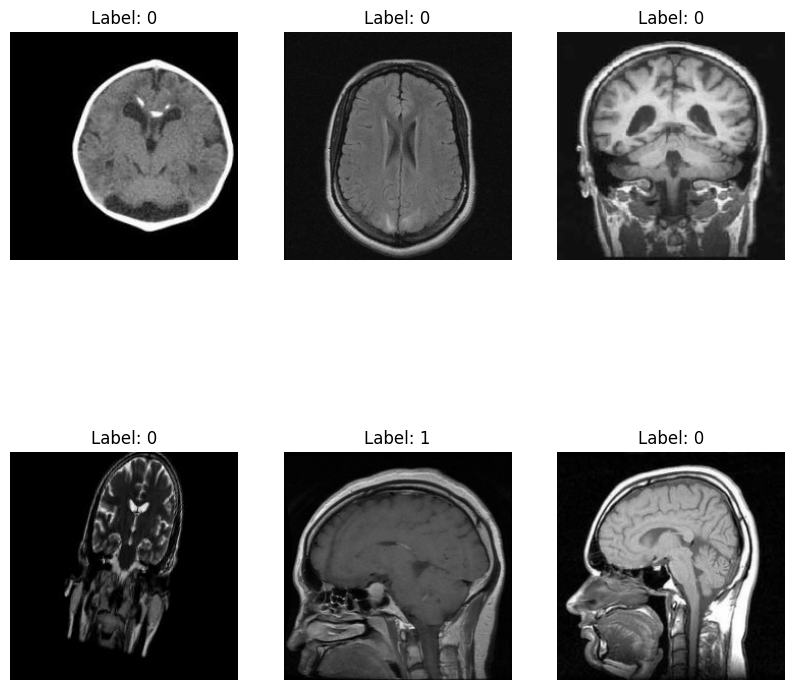

In [8]:
import matplotlib.pyplot as plt
train_ds = train_ds.map(lambda x, y: (x / 255.0, y))

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"Label: {int(labels[i].numpy())}")
        plt.axis("off")
    plt.show()

Modele VGG16

In [9]:
# Modele VGG16

# Nettoyage de la memoire

import tensorflow as tf

from tensorflow.keras import backend as K

import gc

K.clear_session()

gc.collect()


0

In [10]:
# recharger les dataset sans normalisation
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary/Training_balanced",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary/Training_balanced",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary/Testing",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Classes :", train_ds.class_names)

Found 4950 files belonging to 2 classes.
Using 3960 files for training.
Found 4950 files belonging to 2 classes.
Using 990 files for validation.
Found 394 files belonging to 2 classes.
Classes : ['no_tumor', 'tumor']


In [11]:
# Optimisation du modele pour rendre le chargement des données plus rapide et plus fluide

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)

test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)


In [12]:
# Construction du modele
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Base VGG16
base_model = VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

# Modèle complet
inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     65,664 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [13]:
# Compilation
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [14]:
# callsbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    ModelCheckpoint("/content/vgg16_best.keras", save_best_only=True)
]

In [15]:
# Entraînement avec class_weight
class_weight = {
    0: 1.0,
    1: 1.5
}

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weight
)

Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 37s 234ms/step - accuracy: 0.6692 - loss: 1.2705 - val_accuracy: 0.7909 - val_loss: 0.4948 - learning_rate: 1.0000e-04
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 26s 168ms/step - accuracy: 0.8187 - loss: 0.5507 - val_accuracy: 0.8677 - val_loss: 0.2884 - learning_rate: 1.0000e-04
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 21s 172ms/step - accuracy: 0.8573 - loss: 0.4100 - val_accuracy: 0.9000 - val_loss: 0.2284 - learning_rate: 1.0000e-04
Epoch 4/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 22s 180ms/step - accuracy: 0.8965 - loss: 0.3111 - val_accuracy: 0.9131 - val_loss: 0.1928 - learning_rate: 1.0000e-04
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 24s 191ms/step - accuracy: 0.9076 - loss: 0.2773 - val_accuracy: 0.9303 - val_loss: 0.1671 - learning_rate: 1.0000e-04
Epoch 6/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 24s 191ms/step - accuracy: 0.9222 - loss: 0.2456 - val_accuracy: 0.9354 - val_loss: 0.1568 - learning_rate: 1.0000e-04
Epoch 7/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 40s 18

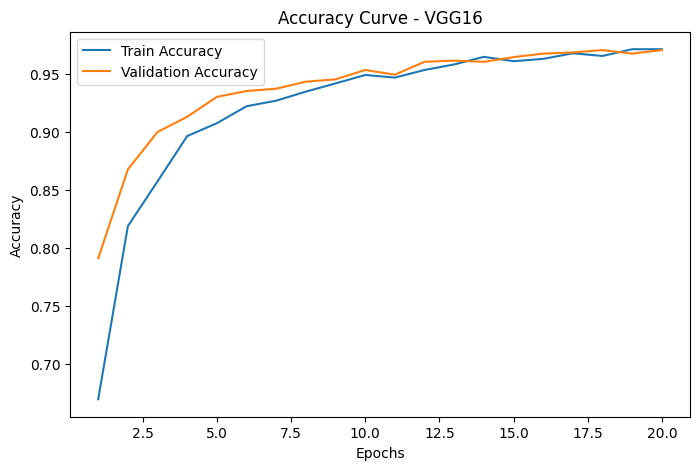

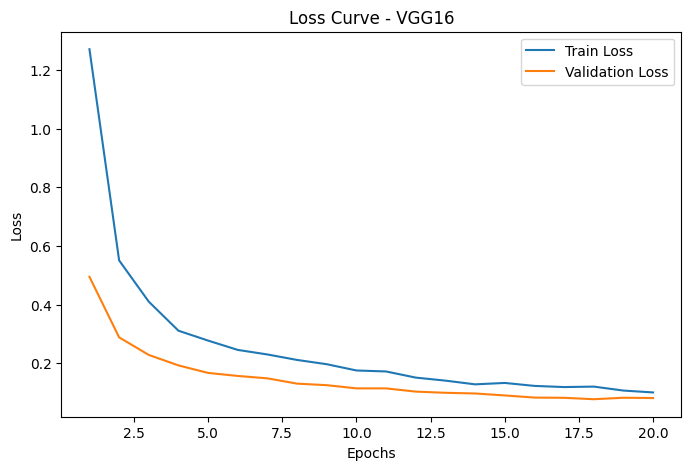

In [16]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]

val_acc = history.history["val_accuracy"]

loss = history.history["loss"]

val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

# ==============================

# ACCURACY

# ==============================

plt.figure(figsize=(8, 5))

plt.plot(epochs_range, acc, label="Train Accuracy")

plt.plot(epochs_range, val_acc, label="Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.title("Accuracy Curve - VGG16")

plt.legend()

plt.show()

# ==============================

# LOSS

# ==============================

plt.figure(figsize=(8, 5))

plt.plot(epochs_range, loss, label="Train Loss")

plt.plot(epochs_range, val_loss, label="Validation Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("Loss Curve - VGG16")

plt.legend()

plt.show()


In [17]:
# Evaluation
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Accuracy VGG16 : {test_acc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 256ms/step - accuracy: 0.8528 - loss: 0.4598
Test Accuracy VGG16 : 0.8528


Le modèle VGG16 obtient une précision similaire à EfficientNet (~83%), confirmant la cohérence du pipeline. Cependant, il n’apporte pas d’amélioration significative, ce qui indique que les performances sont limitées par la complexité des données plutôt que par l’architecture du modèle.


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step

===== Seuil = 0.5 =====
Precision tumor : 0.9676113360323887
Recall tumor    : 0.8269896193771626
F1-score tumor  : 0.8917910447761194
Matrice de confusion :
[[ 97   8]
 [ 50 239]]

===== Seuil = 0.4 =====
Precision tumor : 0.9642857142857143
Recall tumor    : 0.8408304498269896
F1-score tumor  : 0.8983364140480592
Matrice de confusion :
[[ 96   9]
 [ 46 243]]

===== Seuil = 0.3 =====
Precision tumor : 0.9615384615384616
Recall tumor    : 0.8650519031141869
F1-score tumor  : 0.9107468123861566
Matrice de confusion :
[[ 95  10]
 [ 39 250]]

===== Seuil = 0.2 =====
Precision tumor : 0.927536231884058
Recall tumor    : 0.8858131487889274
F1-score tumor  : 0.9061946902654867
Matrice de confusion :
[[ 85  20]
 [ 33 256]]

✅ Meilleur seuil choisi : 0.3

📊 Classification Report final :
              precision    recall  f1-score   support

    no_tumor       0.71      0.90      0.79       105
       tumor       0.96      0.87      0.91       289

    

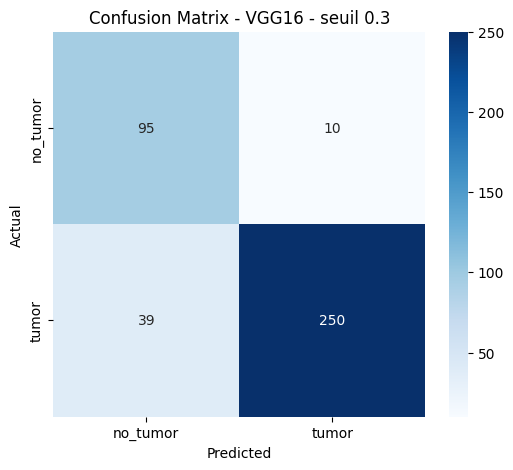

In [18]:
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

# ==============================

# NOMS DES CLASSES

# ==============================

class_names = ['no_tumor', 'tumor']

# ==============================

# VRAIES ETIQUETTES + PROBABILITES

# ==============================

y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

y_prob = model.predict(test_ds).ravel()

# ==============================

# TEST DE PLUSIEURS SEUILS

# ==============================

thresholds = [0.5, 0.4, 0.3, 0.2]

results = []

for threshold in thresholds:

    y_pred = (y_prob > threshold).astype(int)

    precision = precision_score(y_true, y_pred, pos_label=1)

    recall = recall_score(y_true, y_pred, pos_label=1)

    f1 = f1_score(y_true, y_pred, pos_label=1)

    print(f"\n===== Seuil = {threshold} =====")

    print("Precision tumor :", precision)

    print("Recall tumor    :", recall)

    print("F1-score tumor  :", f1)

    print("Matrice de confusion :")

    print(confusion_matrix(y_true, y_pred))

    results.append((threshold, precision, recall, f1))

# ==============================

# CHOIX DU MEILLEUR SEUIL

# ==============================

best_threshold = max(results, key=lambda x: x[3])[0]   # basé sur le F1-score

print("\n✅ Meilleur seuil choisi :", best_threshold)

# ==============================

# RAPPORT FINAL AVEC LE MEILLEUR SEUIL

# ==============================

y_pred_best = (y_prob > best_threshold).astype(int)

print("\n📊 Classification Report final :")

print(classification_report(y_true, y_pred_best, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_best)

plt.figure(figsize=(6, 5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=class_names,

    yticklabels=class_names

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(f"Confusion Matrix - VGG16 - seuil {best_threshold}")

plt.show()


Interprétation
VGG16 donne un bon résultat global, avec une bonne capacité à détecter les tumeurs. Le rappel de la classe tumor reste élevé, mais il est inférieur à celui obtenu avec EfficientNet, ce qui signifie que VGG16 laisse passer davantage de cas tumoraux. Dans un contexte médical, cette différence est importante, car les faux négatifs sont les erreurs les plus critiques.
Conclusion
Après optimisation du seuil à 0.2, le modèle VGG16 atteint une accuracy d’environ 85 % avec un rappel de 0.86 pour la classe tumor. Les résultats sont satisfaisants, mais restent légèrement inférieurs à ceux d’EfficientNet pour la détection des tumeurs. EfficientNet demeure donc le modèle le plus pertinent à ce stade, notamment pour limiter les faux négatifs